In [1]:
import sys
sys.path.append("../")

from brian2 import *
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *

from functions import *

In [2]:

"""- - - - MAIN SIMULATION - - - - """

T = 2000 # ms
N_trials = 100
N_spikes = 40
spike_delay = 4*ms
counts = np.zeros(N_trials)

spike_delays = []

for i in tqdm(range(N_trials)):
    # 1. Setup Input (Presynaptic Neuron)
    # Let's say it fires at 20Hz
    #P = PoissonGroup(1, 20*Hz)
    idx = np.zeros(N_spikes)
    spike_times = np.linspace(10, 3*T/4, N_spikes)*ms
    ms_per_spike = (T/2 - 10)/N_spikes
    firing_frequency = 1000/ms_per_spike
    #print(f"FF: {firing_frequency}")
    P = SpikeGeneratorGroup(1, idx, spike_times)


    # 2. The Poisson Generator Group
    # 'rho' acts as the instantaneous firing rate
    tau_decay = spike_delay     # How long the "influence" of a pre-spike lasts
    gain = 1/(spike_delay)      # How much each pre-spike adds to the output rate

    PoissonGen = NeuronGroup(1, 
        '''
        drho/dt = -rho/tau_decay : Hz  # Rate decays over time
        ''',
        threshold = 'rand() < rho * dt', 
        method = 'euler')

    # 3. Connect Pre-synapse to the Generator
    # Each spike from P increases the firing rate of PoissonGen
    S_in = Synapses(P, PoissonGen, on_pre='rho += gain')
    S_in.connect()

    # 4. Connect Generator to Post-synaptic Target
    Post = NeuronGroup(1, 'dv/dt = -v/(10*ms) : 1', threshold='v>1', reset='v=0')
    S_out = Synapses(PoissonGen, Post, on_pre='v_post += 0.3')
    S_out.connect()


    # Monitors
    mon_p = SpikeMonitor(P)
    mon_gen = SpikeMonitor(PoissonGen, record = True)
    mon_rate = StateMonitor(PoissonGen, 'rho', record=True)
    mon_post = StateMonitor(Post, 'v', record = True)
    spikemon_post = SpikeMonitor(Post, record = True)

    
    run(T*ms)


    spk_trn = mon_gen.spike_trains()[0]
    counts[i] = len(spk_trn)


    for spike in spk_trn:
        #print(spike)
        delay = spike - spike_times[spike_times < spike][-1]    #last spike before the poisson spike
        #print(delay)
        spike_delays.append(delay*1000)


100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


[0.01       0.04820513 0.08641026 0.12461538 0.16282051 0.20102564
 0.23923077 0.2774359  0.31564103 0.35384615 0.39205128 0.43025641
 0.46846154 0.50666667 0.54487179 0.58307692 0.62128205 0.65948718
 0.69769231 0.73589744 0.77410256 0.81230769 0.85051282 0.88871795
 0.92692308 0.96512821 1.00333333 1.04153846 1.07974359 1.11794872
 1.15615385 1.19435897 1.2325641  1.27076923 1.30897436 1.34717949
 1.38538462 1.42358974 1.46179487 1.5       ] s
[  10.           48.20512821   86.41025641  124.61538462  162.82051282
  201.02564103  239.23076923  277.43589744  315.64102564  353.84615385
  392.05128205  430.25641026  468.46153846  506.66666667  544.87179487
  583.07692308  621.28205128  659.48717949  697.69230769  735.8974359
  774.1025641   812.30769231  850.51282051  888.71794872  926.92307692
  965.12820513 1003.33333333 1041.53846154 1079.74358974 1117.94871795
 1156.15384615 1194.35897436 1232.56410256 1270.76923077 1308.97435897
 1347.17948718 1385.38461538 1423.58974359 1461.794871

Text(0, 0.5, 'v [mV]')

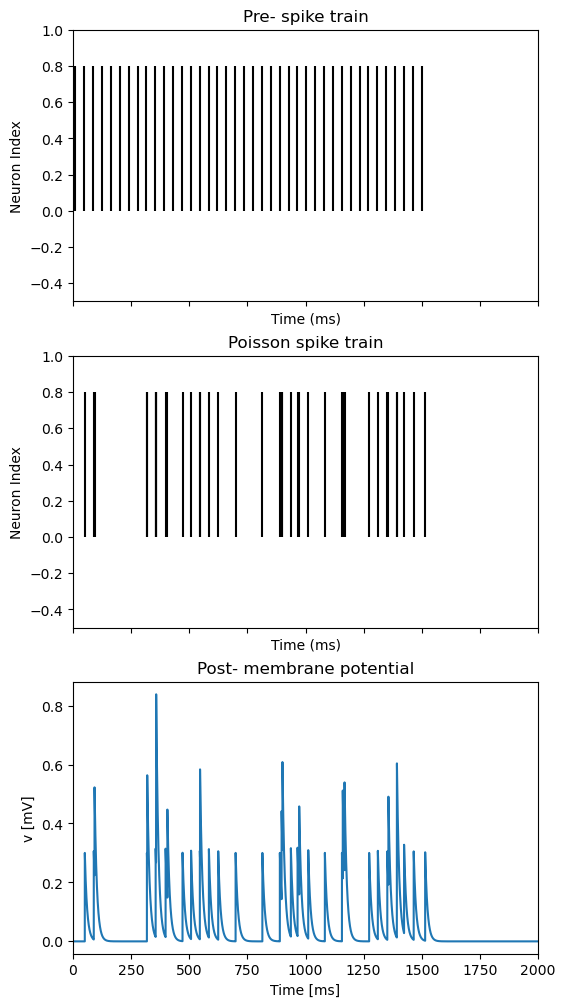

In [3]:
fig, ax = plt.subplots(3, 1, figsize = (6, 12), sharex = True)

print(spike_times)

plot_raster(np.array([spike_times/ms]), T, ax = ax[0])
ax[0].set_title("Pre- spike train")

plot_raster(np.array([spk_trn/ms]), T, ax = ax[1])
ax[1].set_title("Poisson spike train")

ax[2].plot(mon_post.t/ms, mon_post.v[0])
ax[2].set_title("Post- membrane potential")
ax[2].set_xlabel("Time [ms]")
ax[2].set_ylabel("v [mV]")

DEFAULT DT: 0.1 ms^2
Mean: 38.48
STD: 5.7384318415399855
Mean Ratio = 0.962
STD Ratio = 0.14346079603849965


Text(0.5, 0, 'Time (ms)')

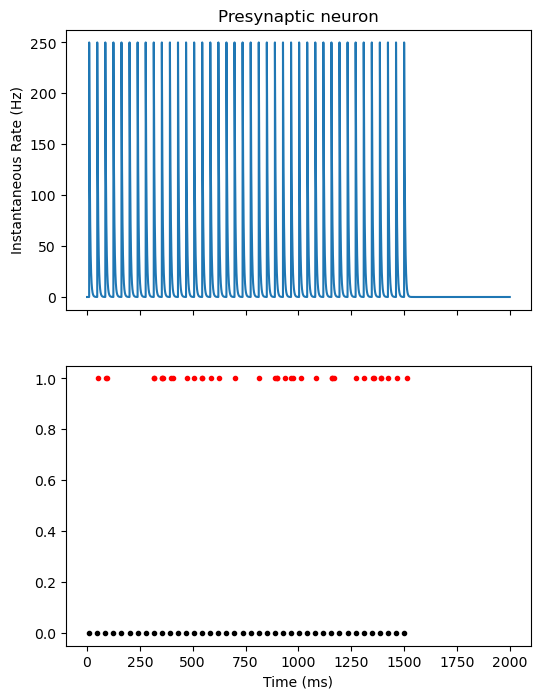

In [4]:
# Visualization of the frequency transformation
print(f"DEFAULT DT: {defaultclock.dt*ms}")


avg_poiss = np.mean(counts)
std_poiss = np.std(counts)
print(f"Mean: {avg_poiss}")
print(f"STD: {std_poiss}")
print(f"Mean Ratio = {avg_poiss/N_spikes}")
print(f"STD Ratio = {std_poiss/N_spikes}")

fig, ax = plt.subplots(2, 1, figsize = (6, 8), sharex = True)

ax[0].plot(mon_rate.t/ms, mon_rate.rho[0]/Hz)
ax[0].set_title('Presynaptic neuron')
ax[0].set_ylabel('Instantaneous Rate (Hz)')


ax[1].plot(mon_p.t/ms, mon_p.i, '.k', label='Pre-synaptic')
ax[1].plot(mon_gen.t/ms, mon_gen.i + 1, '.r', label='Poisson Gen')
ax[1].set_xlabel('Time (ms)')


Text(0, 0.5, 'Time delay of synapse [ms]')

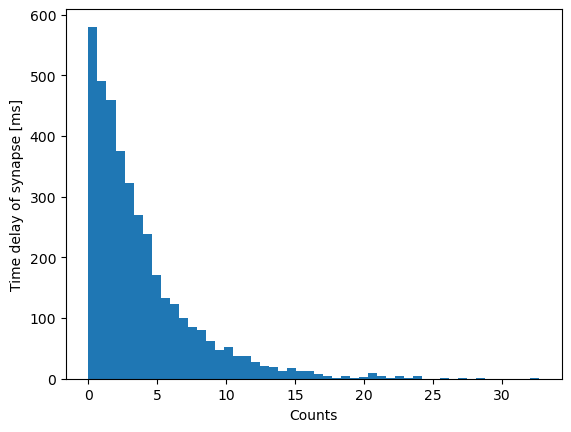

In [5]:

plt.hist(spike_delays, bins = 50)
plt.xlabel("Counts")
plt.ylabel("Time delay of synapse [ms]")